# EDA NOTEBOOK

## I. Introduction and Setup

### 1. Introduction

**Notebook này thực hiện Exploratory Data Analysis (EDA)** trên bộ dữ liệu 
[UCI Heart Disease Dataset] để hiểu sâu về cấu trúc dữ liệu
, phân phối của các đặc trưng, mối tương quan giữa các biến,
và các vấn đề cần xử lý trước khi xây dựng mô hình.

### 2. EDA Roadmap

| Bước | Nội dung | Người thực hiện |
|------|----------|-----------------|
| I | Introduction & Setup | Cả nhóm |
| II | Target Analysis | Quyên |
| III | Categorical Analysis | Quyên |
| IV | Distribution Analysis | Phát |
| V | Correlation Analysis | Phát |
| VI | Outlier Detection | Xuyên |
| VII | Statistical Tests | Xuyên |

### 3. Environment Setup and Library Import

In [1]:
#import library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

#hàm load data set để handle error và tái sử dụng
def load_dataset(dataset_path):
    """
    Kiểm tra và lấy dữ liệu từ file csv 
    Args:
        dataset_path (str): đường dẫn file csv 
    Returns:
        pandas.dataframe: bảng dữ liệu đã được đọc
    """
    if not os.path.exists(dataset_path):
        print("Không tìm thấy file!")
        return None
    
    try: 
        df = pd.read_csv(dataset_path)
        print("Đã tải dữ liệu thành công!")
        return df
    except Exception as e:
        print(f"Đã xảy ra lỗi trong quá trình tải: {e}")
        return None
    
#define dataset path
dataset_path = "../data/dataset.csv"

#load data
df = load_dataset(dataset_path=dataset_path)

Đã tải dữ liệu thành công!


### 4. Data Overview
Đây là tập dữ liệu thô được lấy từ nguồn **[UCI Heart Disease Dataset]**

Link: https://archive.ics.uci.edu/dataset/45/heart+disease

In [2]:
#Hiển thị tổng quan về các thông tin của dataset: số hàng, số cột, kiểu dữ liệu, số giá trị non-null mỗi cột, ...
print("Tổng quan cấu trúc dataset:")

#Thông tin số dòng số cột
print(f"- Dataset có {df.shape[0]} dòng và {df.shape[1]} cột.")

Tổng quan cấu trúc dataset:
- Dataset có 920 dòng và 16 cột.


In [3]:
#Thông tin kiểu dữ liệu từng cột, số giá trị non-null
print("- Các thông tin cơ bản:")
df.info()

- Các thông tin cơ bản:
<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [ ]:
#Thông tin về trung bình, độ lệch chuẩn, tứ phân vị, giá trị nhỏ nhất lớn nhất
print("- Các thông tin thống kê numerical:")
display(df.describe())
print("- Các thông tin thống kê categorical:")
display(df.describe(include='object'))

- Các thông tin thống kê numerical:


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


- Các thông tin thống kê categorical:


,sex,dataset,cp,fbs,restecg,exang,slope,thal
count,920,920,920,830,918,865,611,434
unique,2,4,4,2,3,2,3,3
top,Male,Cleveland,asymptomatic,False,normal,False,flat,normal
freq,726,304,496,692,551,528,345,196


In [5]:
#5 hàng dữ liệu đầu tiên
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


### 5. Add target variable
Sau khi xem xét các thuộc tính của dataset, nhóm nhận thấy rằng thuộc tính 'num' của dataset là thuộc tính giúp phân loại người bệnh và không có bệnh. Nhưng giá trị của thuộc tính num này là kiểu int64 có giá trị từ **0 đến 4**, trong đó, 0 là không bệnh và 1 2 3 là có bệnh. Để phục vụ giải quyết bài toán **Classification**, nhóm quyết định thêm cột 'target' kiểu binary:
* 0: Không bệnh (num = 0)
* 1: Có bệnh (num = 1, 2, 3, 4)

Cột 'num' được giữu lại để tham khảo sau này và đúng với nguyên tắc không chỉnh sửa dữ liệu thô.


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,target
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2,1
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0,0


## II. Target Analysis

**Phân tích biến mục tiêu (Target Analysis):** Là quá trình thống kê và hình ảnh hóa để hiểu rõ đặc điểm, phân phối và tính chất của biến dự đoán trước khi xây dựng mô hình. Phân tích biến mục tiêu giúp ta xác định:
*     Dữ liệu có cân bằng hay không?
*     Chỉ số đánh giá phù hợp?
*     Các vấn đề về chất lượng dữ liệu?

#Hiển thị dữ liệu đã thêm target
df.head()

## II. Target Analysis
**Phân tích biến mục tiêu (Target Analysis):** Là quá trình thống kê và hình ảnh hóa để hiểu rõ đặc điểm, phân phối và tính chất của biến dự đoán trước khi xây dựng mô hình. Phân tích biến mục tiêu giúp ta xác định:
*     Dữ liệu có cân bằng hay không?
*     Chỉ số đánh giá phù hợp?
*     Các vấn đề về chất lượng dữ liệu?


Trong phần này, nhóm sử dụng biểu đồ **CountPlot** để thực hiện Target Analysis (Phân tích biến mục tiêu). Biến mục tiêu được xác định là **cột 'num'** – cột lưu trữ kết quả chẩn đoán bệnh tim của bệnh nhân. Để phù hợp với yêu cầu bài toán phân loại (có bệnh/không có bệnh), nhóm đã tiến hành nhị phân hóa cột dữ liệu này, trong đó giá trị 0 đại diện cho trạng thái **'Không bệnh'** và các giá trị từ 1 đến 4 đại diện cho trạng thái **'Có bệnh'**.

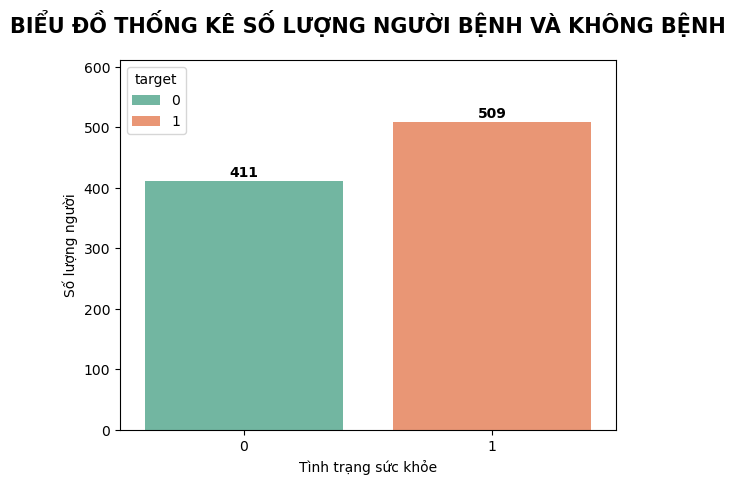

In [17]:
def plot_target_distribution(data, column='target'):
    """
    Hàm vẽ biểu đồ đếm số lượng cho biến mục tiêu.
    data: DataFrame chứa dữ liệu
    column: Tên cột muốn vẽ (mặc định là 'target')
    """
    # Vẽ biểu đồ
    ax = sns.countplot(data=data, x=column, hue=column, palette="Set2", legend=True)

    # Gắn nhãn số lượng trên đầu mỗi cột
    for container in ax.containers:
        ax.bar_label(container, fontsize=10, fontweight='bold', padding=1)

    # Thiết lập tiêu đề và các trục
        counts = data[column].value_counts()
        ax.set_ylim(0, counts.max() * 1.2)
    plt.title('BIỂU ĐỒ THỐNG KÊ SỐ LƯỢNG NGƯỜI BỆNH VÀ KHÔNG BỆNH',
              fontsize=15,
              fontweight='bold',
              pad=20)
    plt.xlabel('Tình trạng sức khỏe')
    plt.ylabel('Số lượng người')

    # Hiển thị
    plt.show()


plot_target_distribution(df)

**Nhận xét:**
* **Số lượng:** Có **411** trường hợp không mắc bệnh và **509** trường hợp mắc bệnh.
* **Độ cân bằng:** Dữ liệu có tính cân bằng cao.
* **Chiến lược đánh giá:** Ưu tiên chỉ số Recall để giảm thiểu tỷ lệ bỏ sót bệnh nhân.

**Chú thích:**
* 0:Không bệnh
* 1:Có bệnh


## III. Categorical Analysis
**Phân tích biến phân loại(Categorical Analysis)** là việc nghiên cứu các biến chứa các giá trị định tính, nhãn hoặc các nhóm hữu hạn (ví dụ: giới tính, quốc gia, loại sản phẩm) thay vì các con số liên tục. Mục tiêu chính của bước này là hiểu được sự phân phối, tần suất xuất hiện và mối quan hệ của các nhóm dữ liệu này với các biến khác.

Trong phần này nhóm sử dụng biểu đồ CountPlot để phân tích biến phân loại.

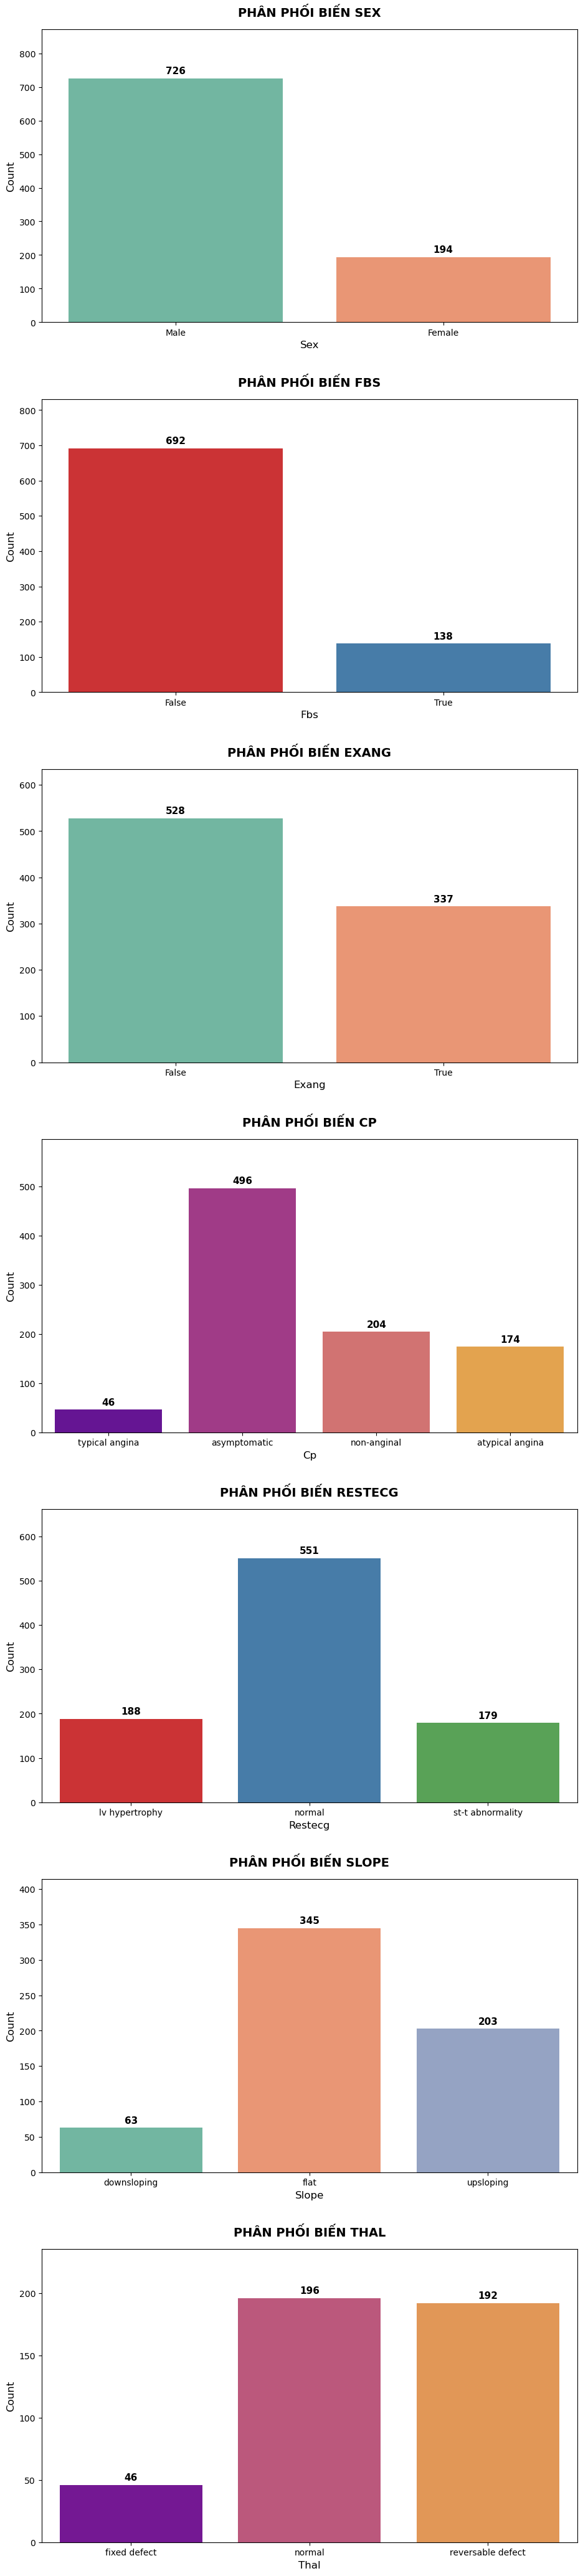

In [18]:
def plot_categorical(df, configs):
    """
    Vẽ các biểu đồ countplot cho danh sách các biến phân loại (Categorical).

    Hàm này tự động tạo ra một lưới các biểu đồ xếp dọc, gắn nhãn số lượng trên đầu mỗi cột
    và tinh chỉnh các thông số hiển thị để báo cáo trông chuyên nghiệp hơn.

    Args:
        df (pd.DataFrame): Bảng dữ liệu chứa các biến cần phân tích.
        configs (list of tuples): Danh sách cấu hình biểu đồ. Mỗi tuple bao gồm:
            (tên_cột_x, tên_cột_hue, tên_palette).
            Nếu x == hue, hàm sẽ hiểu là vẽ phân phối đơn biến.

    Returns:
        None: Hàm hiển thị biểu đồ trực tiếp bằng plt.show().
    """
    # Tạo khung hình động dựa trên số lượng biểu đồ
    fig, axes = plt.subplots(nrows=len(configs), ncols=1, figsize=(10, 6 * len(configs)))

    # Trường hợp chỉ có 1 biểu đồ, Matplotlib trả về 1 object thay vì list, cần ép về list
    if len(configs) == 1:
        axes = [axes]

    for i, (x_col, h_col, pal) in enumerate(configs):
        ax = axes[i]
        is_univariate = (x_col == h_col)

        # Vẽ biểu đồ chính
        sns.countplot(data=df, x=x_col, hue=h_col, palette=pal, ax=ax, legend=not is_univariate)

        # Gắn nhãn số lượng trên đầu mỗi cột
        for container in ax.containers:
            ax.bar_label(container, fontsize=11, fontweight='bold', padding=3)

        # Tinh chỉnh tiêu đề (Tự động nhận diện đơn biến hay đa biến)
        title_text = f'PHÂN PHỐI BIẾN {x_col.upper()}' if is_univariate else f'TỶ LỆ BỆNH THEO {x_col.upper()}'
        ax.set_title(title_text, pad=15, fontsize=14, fontweight='bold')
        ax.set_xlabel(x_col.capitalize(), fontsize=12)
        ax.set_ylabel('Count', fontsize=12)

        # Giữ chữ trên trục X nằm ngang cho dễ đọc
        if x_col in ['cp', 'restecg', 'slope', 'thal']:
            ax.tick_params(axis='x', rotation=0)

        # Chỉnh ylim để các nhãn bar_label không bị chạm đỉnh khung hình
        counts = df[x_col].value_counts()
        ax.set_ylim(0, counts.max() * 1.2)

    plt.tight_layout(pad=3.0)
    plt.show()

# --- Thực thi ---
my_configs = [
    ('sex', 'sex', 'Set2'),
    ('fbs','fbs','Set1' ),
    ('exang','exang', 'Set2'),
    ('cp', 'cp', 'plasma'),
    ('restecg','restecg','Set1' ),
    ('slope', 'slope', 'Set2'),
    ('thal','thal', 'plasma')
]

plot_categorical(df=df, configs=my_configs)

**Nhận xét:**

**-Tại biểu đồ 1:** Dữ liệu có sự mất cân bằng giới tính. Số lượng Nam giới tham gia khảo sát đông hơn rất nhiều so với Nữ giới (726 Nam so với 194 Nữ).

**-Tại biểu đồ 2:** Đau ngực loại asymptomatic (không triệu chứng) chiếm tỷ lệ cao nhất (496 ca). Các loại đau thắt ngực điển hình (typical angina) chiếm tỷ lệ thấp nhất (46 ca).

**-Tại biểu đồ 3:** Đa số người tham gia có đường huyết lúc đói dưới 120 mg/dl (692 ca). Chỉ có một nhóm nhỏ (138 ca) có chỉ số đường huyết cao (> 120 mg/dl).

**-Tại biểu đồ 4:** Số lượng người không bị đau ngực khi vận động (False - 528 ca) cao hơn đáng kể so với nhóm có bị đau ngực khi vận động (True - 337 ca).

**-Tại biểu đồ 5:** Kết quả điện tâm đồ lúc nghỉ ngơi phần lớn là normal (551 ca). Các tình trạng bất thường như lv hypertrophy hay st-t abnormality chiếm số lượng ít hơn và khá tương đồng nhau.

**-Tại biểu đồ 6:** Độ dốc của đoạn ST sau tập luyện chủ yếu là flat (345 ca) và upsloping (203 ca). Loại downsloping chiếm tỷ lệ rất thấp (63 ca).

**-Tại biểu đồ 7:** Tình trạng thiếu máu cục bộ cơ tim phổ biến nhất là normal (196 ca) và reversable (192 ca). Loại fixed defect chỉ chiếm một phần nhỏ (46 ca).

**Kết luận:** Tập dữ liệu cho thấy đối tượng khảo sát điển hình là Nam giới, có kết quả điện tâm đồ bình thường, nhưng phần lớn lại gặp tình trạng đau ngực không triệu chứng (asymptomatic). Đây là một điểm đáng lưu ý vì bệnh có thể tiến triển âm thầm mà không có biểu hiện đau thắt ngực điển hình.

### IV. Distribution Analysis
**Phân tích phân phối (Distribution Analysis)** là quan sát các giá trị trong một cột dữ liệu được phân bố như thế nào và dữ liệu được tập trung ở đâu hay dữ liệu có bị lệch hay không?
Phân tích phân phối giúp ta xác định: 
* Dữ liệu có bị lệch hay không?
* Feature nào quan trọng với mô hình?
* Feature nào không quan trọng?

Ở đây, nhóm chọn biểu đồ **KDE ()** vì biểu đồ này thể hiện sự chồng lên nhau của 2 nhóm có bệnh và không bệnh rõ ràng nhất.


Trong phần này, nhóm sẽ tập chung phân tích các cột dữ liệu là: age, trestbps, chol, thalch, oldpeak vì các cột này có dữ liệu là numerical liên tục trong 1 khoảng.

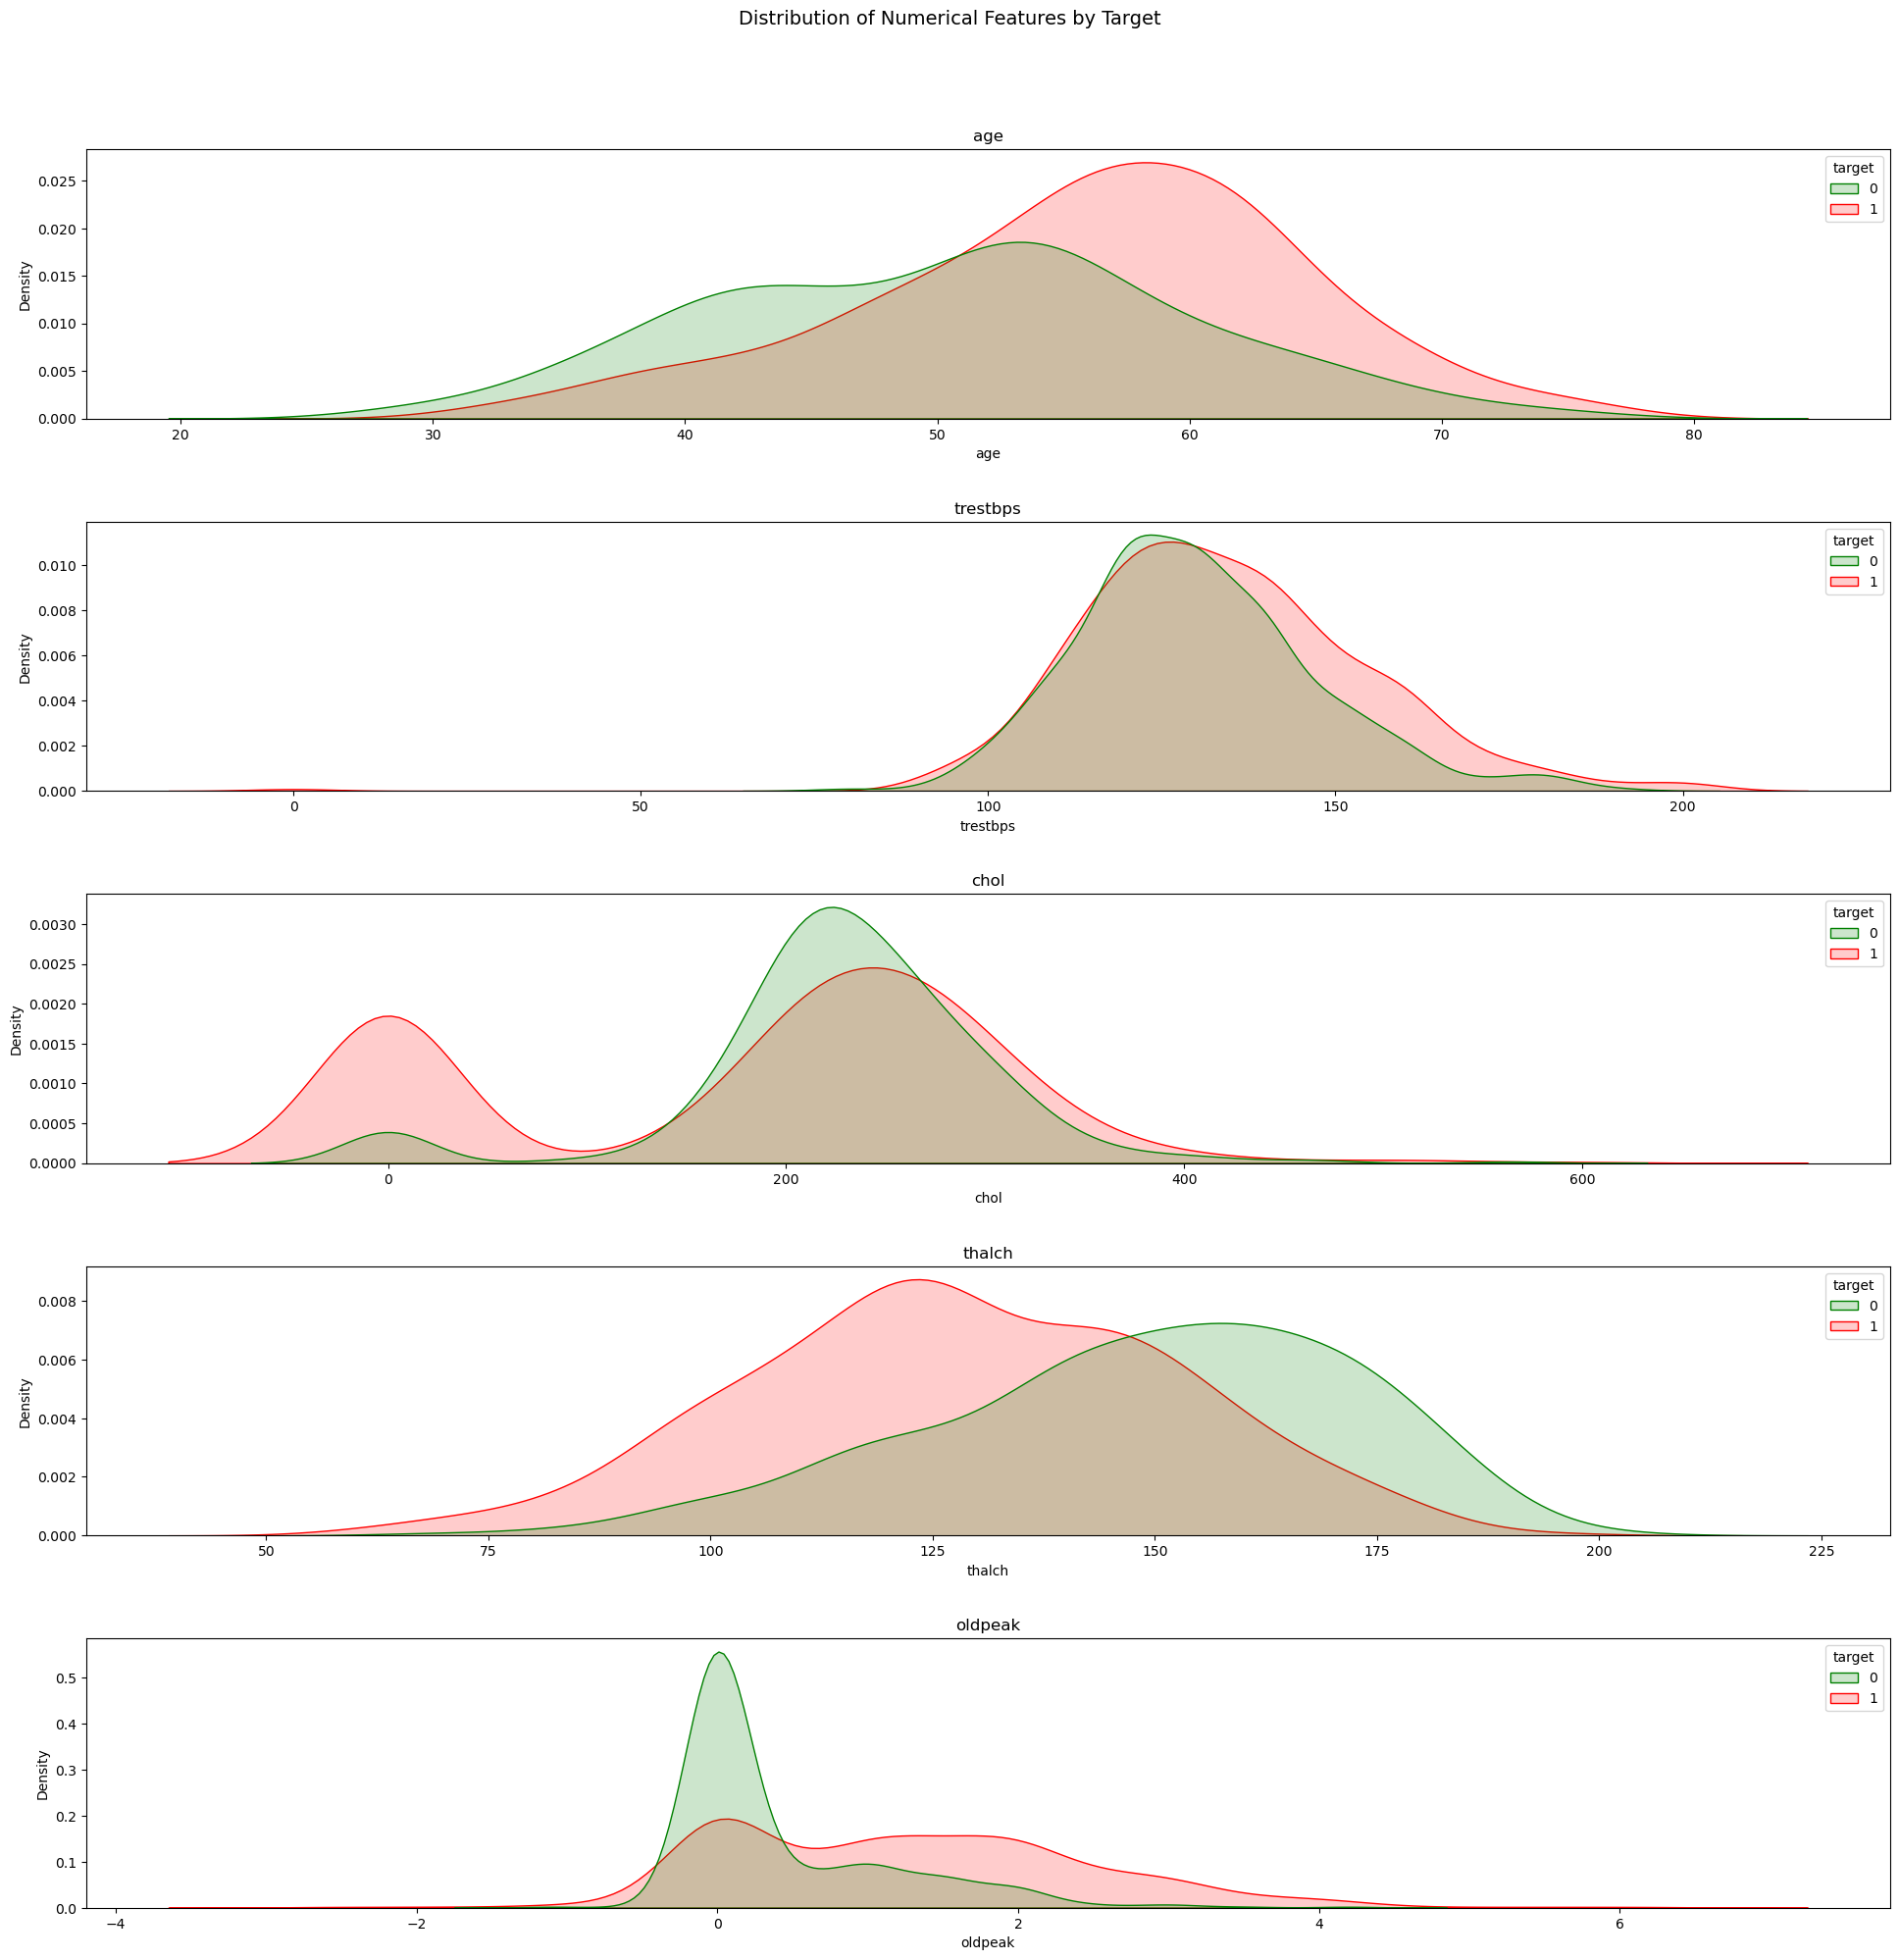

In [19]:
#hàm vẽ biểu đồ KDE cho nhiều cột trong bảng
def plot_distribution(df, num_cols, target='target'):
    """
    Vẽ biểu đồ KDE cho các cột numerical chia thành 2 đối tượng có bệnh và không bệnh bằng biến target
    Args:
        df (pandas.DataFrame): tập dữ liệu đầu vào
        cols (list): danh sách tên các cột cần vẽ biểu đồ
        target (str): tên cột target
    """
    #khung hình gồm 1 hàng và n cột mỗi cột là 1 biểu đồ, với n là số biểu đồ muốn vẽ
    fig, axes = plt.subplots(len(num_cols), 1, figsize=(20, 20))
    
    #lặp qua từng cột, i = vị trí, col = giá trị tên cột
    for i, col in enumerate(num_cols):
        #hàm vẽ biểu đồ KDE của thư viên seaborn
        sns.kdeplot(
            data=df,
            x=col,
            hue=target,
            ax=axes[i],
            fill=True,
            alpha=0.2,
            palette={0: "green", 1: "red"}
        )
        
        #Tiêu đề cho biểu đồ đang vẽ
        axes[i].set_title(col)
        
        #Nhãn của trục x
        axes[i].set_xlabel(col)
        
    plt.suptitle('Distribution of Numerical Features by Target',
                 fontsize=14, y=1.01)
    plt.tight_layout(pad=3.0)    
    
    # #Lưu hình ảnh biểu đồ
    # try:
    #     plt.savefig("../report/figures/distribution_analysis.png")
    #     print('Lưu hình ảnh thành công')
    # except Exception as e:
    #     print(f'Lỗi lưu ảnh: {e}')
        
    plt.show()

#Tạo danh sách tên cột cần vẽ
num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

plot_distribution(df=df, num_cols=num_cols)

**Nhận xét:** 
* **age**: 
    * Nhóm không bệnh phân bố tập trung ở độ tuổi 40 - 55
    * Nhóm có bệnh phân bố tập trung ở độ tuổi 55 - 60

    Hai nhóm có chồng lên nhau nhưng dữ liệu có phần lệch hơn về phía bên phải

    -> Feature này có giá trị trung bình
* **trestbps**:

    Hai nhóm phân phối lệch phải và gần như chồng lên nhau

    -> Feature này có giá trị yếu
* **chol**:

    Hai nhóm phân phối lệch trái và gần như chồng lên nhau

    -> Feature này có giá trị yếu
* **thalch**:

    Nhóm không bệnh phân bố tập trung ở mức nhịp tim cao, từ 150 - 165

    Nhóm có bệnh phân bố tập trung ở mức nhịp tim thấp hơn, từ 120 - 135

    Hai nhóm tách biệt nhau khá rõ ràng và ít bị chồng chéo, điểm giao cắt rõ nét ở khoảng 145 - 150.

    -> Feature này có giá trị phân loại cao (mạnh nhất).
* **oldpeak**:

    Nhóm không bệnh phân bố tập trung rất cao tại mốc 0.

    Nhóm có bệnh phân bố trải dài hơn, tạo thành các khoảng tập trung ở gần mốc 0 và từ 1.0 đến 2.5.

    Hai nhóm có chồng lên nhau ở mốc 0 nhưng hình dáng khác biệt rõ rệt. Dữ liệu của nhóm có bệnh có phần đuôi dài, lệch hẳn về phía bên phải (lên tới mức 4.0 trở lên).

    -> Feature này có giá trị cao.
    
**=> Tóm lại**, trong các đặc trưng trên, **thalch** và **oldpeak** mang lại giá trị phân loại mạnh nhất. **age** có giá trị ở mức trung bình. Cần tập trung vào các feature này, đồng thời cân nhắc loại bỏ các feature yếu (trestbps, chol) để tránh nhiễu và tối ưu hiệu suất mô hình.


## V. Correlation Analysis

**Phân tích tương quan (Correlation Analysis)** là phương pháp thống kê đánh giá mức độ liên quan giữa 2 hoặc nhiều biến số. 

Phân tích tương quan giúp ta xác định:

- Feature nào liên quan mạnh nhất đến bệnh tim?
- Có 2 feature nào mang thông tin trùng lặp nhau không?
- Feature nào nên ưu tiên khi xây dựng mô hình?

Ở đây, nhóm chọn biểu đồ **Heatmap** vì biểu đồ này thể hiện
toàn bộ mối quan hệ giữa tất cả các feature cùng lúc thông qua
màu sắc — màu càng đậm thì tương quan càng mạnh.

Hệ số tương quan có giá trị từ -1 đến 1, trong đó 1 là
tương quan thuận hoàn toàn, 0 là không có tương quan, và -1
là tương quan nghịch hoàn toàn.

Trong phần này, nhóm sẽ encode các cột categorical sang dạng số
trước khi tính tương quan vì hệ số Pearson chỉ tính được trên dữ
liệu số. Việc encode chỉ dùng trong section này, không thay đổi
dữ liệu gốc.

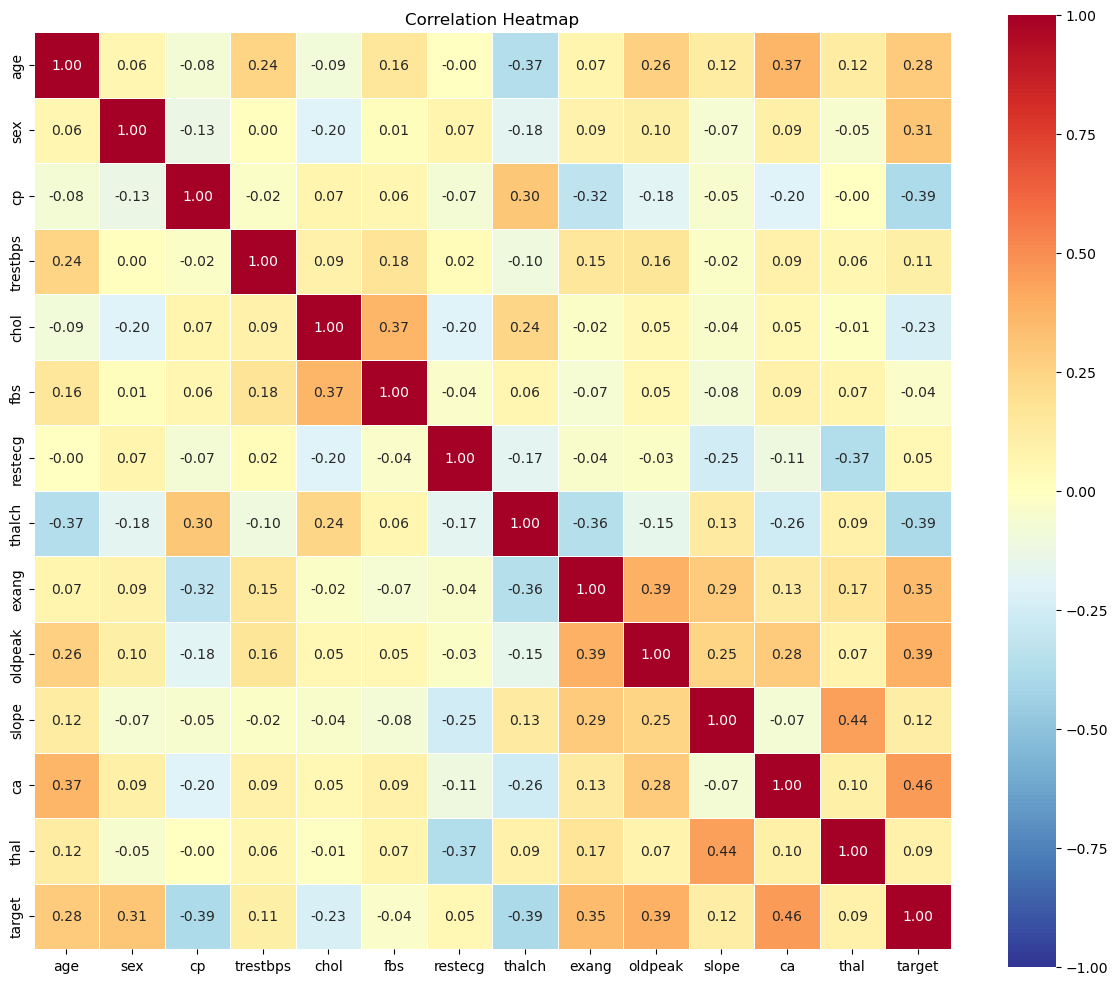

tương quan các cột với target theo độ mạnh:
ca          0.46
thalch     -0.39
oldpeak     0.39
cp         -0.39
exang       0.35
sex         0.31
age         0.28
chol       -0.23
slope       0.12
trestbps    0.11
thal        0.09
restecg     0.05
fbs        -0.04
Name: target, dtype: float64


In [20]:
def encode_categorical(df, cat_cols):
    """
    Encode các categorical feature
    Args:
        df (pandas.DataFrame): tập dữ liệu đầu vào
        cat_cols (list): danh sách các cột là categorical
    Returns:
        (pandas.DataFrame): tập dữ liệu dã được encode
    """
    #tạo bản sao của df để encode mà không làm thay đổi dữ liệu gốc
    df_encoded = df.copy()
    
    #dùng Categorical().codes để encode thành số tự động
    for col in cat_cols:
        df_encoded[col] = pd.Categorical(df_encoded[col]).codes
    
    return df_encoded

def plot_correlation(df, target='target'):
    """
    Vẽ biểu đồ heatmap.
    Args:
        df (pandas.DataFrame): tập dữ liệu đầu vào
        target (str): tên cột target
    """

    #encode các cột categorical để tính hệ số pearson
    cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
    df_encoded = encode_categorical(df, cat_cols=cat_cols)
    
    #trong biểu đồ heatmap này các cột id, dataset không có ý nghĩa so sánh và cột num đã được chuyển thành target, nên không cần dùng các cột này
    df_encoded = df_encoded.drop(columns=['id', 'dataset', 'num'])
    
    #tính ma trận tương quan
    corr_matrix = df_encoded.corr()
    
    #vẽ heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        corr_matrix,
        annot=True,          
        fmt='.2f',           
        cmap='RdYlBu_r',     
        center=0,            
        vmin=-1, vmax=1,     
        linewidths=0.5,      
        square=True          
    )
    plt.title('Correlation Heatmap')
    plt.tight_layout()
    plt.show()
    
    print('tương quan các cột với target theo độ mạnh:')
    print(corr_matrix[target].drop(target).sort_values(key=abs,ascending=False).round(2))
    
plot_correlation(df)

**Nhận xét:**
* Các feature tương quan mạnh với target (|r| > 0.3):

| Feature | Hệ số | Ý nghĩa |
|---|---|---|
| ca | +0.46 | Số mạch vành bị tắc càng nhiều -> nguy cơ bệnh càng cao |
| thalch | -0.39 | Nhịp tim tối đa càng thấp -> nguy cơ bệnh càng cao |
| oldpeak | +0.39 | ST depression càng cao -> nguy cơ bệnh càng cao |
| cp | -0.39 | Loại đau ngực có liên quan rõ đến bệnh tim |
| exang | +0.35 | Đau ngực khi gắng sức -> dấu hiệu rõ của bệnh tim |
| sex | +0.31 | Giới tính có ảnh hưởng đến nguy cơ bệnh tim |

* Những feature còn lại có tương quan yếu hoặc gần như không tương quan với target

* Những feature có tương quan mạnh với nhau:

| Cặp Feature | Hệ số | Ý nghĩa |
|---|---|---|
| slope vs thal | +0.44 | Khá trùng lặp |
| exang vs oldpeak | +0.39 | Có liên quan nhau |
| chol vs fbs | +0.37 | Cholesterol cao đi đôi với đường huyết cao |
| ca vs age | +0.37 | Người lớn tuổi -> mạch vành dễ bị tắc hơn |
| thalch vs age | -0.37 | Người lớn tuổi -> nhịp tim tối đa thấp hơn |
| thal vs restecg | -0.37 | Kết quả thalassemia liên quan đến ECG |
| thalch vs exang | -0.36 | Nhịp tim tối đa thấp đi đôi với đau ngực khi gắng sức |
| exang vs cp | -0.32 | Loại đau ngực liên quan đến đau khi gắng sức |

**=> Tóm lại,**

- Các feature tương quan mạnh với target có: ca, thalch, oldpeak, cp, exang và sex
-> ưu tiên giữ lại các feature này.

- Các feature tương quan yếu có: thal, restecg và fbs
-> cân nhắc bỏ bớt

- Các cặp feature có tương quan mạnh có: slope và thal, exang và oldpeak
-> cân nhắc bỏ bớt 1 trong mỗi cặp